In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import typing as t

In [ ]:
import statsmodels as sm

# 1. Загрузка временного ряда и изменение частоты дискретизации данных

Основной проблемой алгоритмов ARIMA/SARIMA является алгоритмическая сложность обучения: из-за того, что в процессе подбора коэффициентов производится операция возведение матрицы в степень, нам может не хватать оперативной памяти, чтобы сформировать модель. Именно из-за этого весь ноутбук крашится, среда вылетает. А весь прогресс сбрасывается.

Чтобы избежать этой проблемы, можно воспользоваться одним из двух способов.

**Первый способ**: сокращение обучающей выборки. Самый простой и безболезненный подход, мы прсото слева отсекаем временные наблюдения. Можно это обосновать тем, что на значения из краткосрочного будущего больше влияют последние наблюдения, нежели те, которые были когда-то давно.

Особенно подход актуален для данных, в которых большое количество наблюдений. Однако если в них наблюдается периодичность (сезон/цикл) с большим лагом (например, даные дневные, сезон на 365 дней), то решению исходной проблемы это особо не поможет.

Поэтому появляется **второй способ**: агрегация временного ряда. Представим, что данные у нас дневные. Мы хотим "схлопнуть" эти временные метки, чтобы частотой был не день, а, например, неделя. Чтобы это сделать, необходимо с окном в 7 лагов пройтись по временным наблюдениям, за 7 дней усреднить (можно использовать другие статистики) значения и поместить их в новый датасет, который будет в 7 раз меньше (так как в неделе 7 дней).

В результате в данных сохраняется структура: тренд, сезоны/циклы, а влияние шумов уменьшено. Однако нужно контролировать размер новой частоты. Если бы новой частотой дискретизации была не неделя, а месяц, возможно, такие чувствительные данные, как температура, могли бы потерять полезные зависимости (в разные недели одного месяца средняя температура может существенно отличаться).

Попробуем воспользоваться вторым вариантом и дневные данные превратить в недельные.

In [ ]:
train = pd.read_csv('/content/train_min_temps.csv', parse_dates=['Date'])
test = pd.read_csv('/content/test_min_temps.csv', parse_dates=['Date'])

In [ ]:
train

,Date,linear
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
2734,1988-06-27,10.0
2735,1988-06-28,6.7
2736,1988-06-29,9.4
2737,1988-06-30,9.3


Если данные были уже разделены, то их сначала нужно объединить в один датасет, а затем уже выполнять агрегацию. Это сделано для того, чтобы не нарушить временную структуру между настоящим, прошлым и будущим. И чтобы корректно, в дальнейшем, выделить train и test.

In [ ]:
df = pd.concat([train, test], axis=0).reset_index().drop(columns=['index'])
df

,Date,linear
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3647,1990-12-27,14.0
3648,1990-12-28,13.6
3649,1990-12-29,13.5
3650,1990-12-30,15.7


Рассмотрим разные варианты агрегации данных:
1. по неделям (сокращает датасет в 7 раз);
2. по месяцам (в 30 раз);
3. по кварталам (в 120 раз);
4. по годам (в 365 раз).

Для этого на одном графике нанесем исходные (дневные данные), а также сгруппированные.

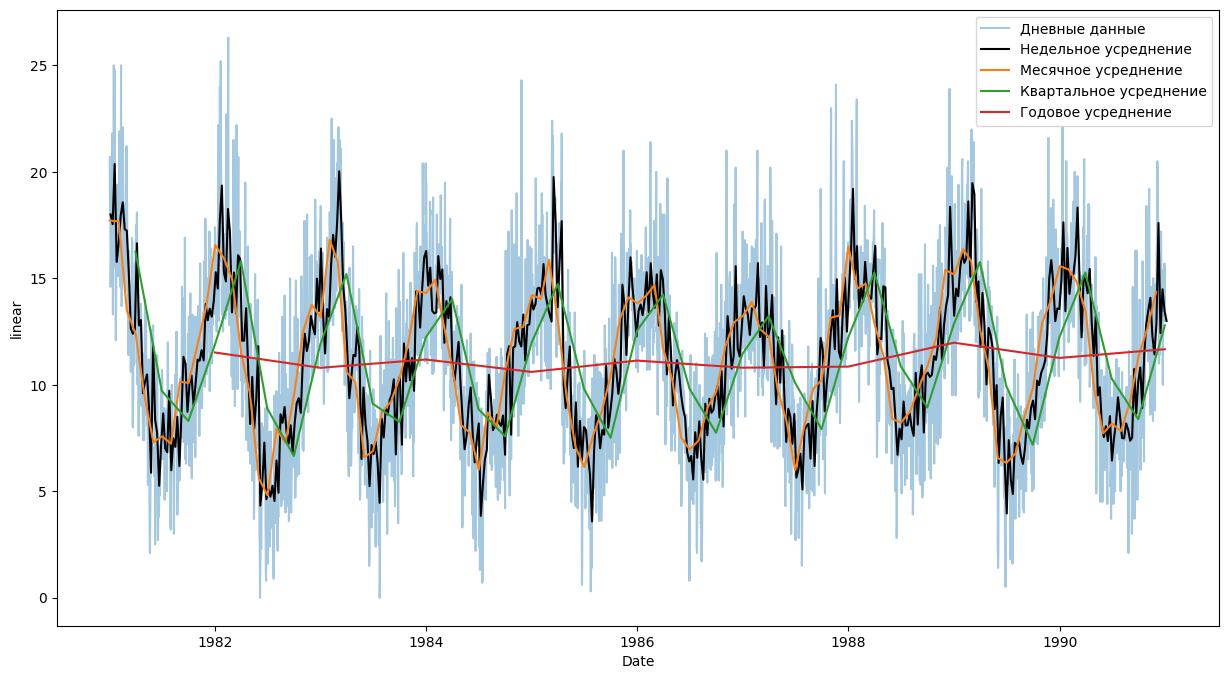

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.lineplot(df.set_index('Date')['linear'], ax=ax, alpha=0.4, label='Дневные данные')
sns.lineplot(df.set_index('Date').resample('W')['linear'].mean(), ax=ax, color='black', label='Недельное усреднение')
sns.lineplot(df.set_index('Date').resample('MS')['linear'].mean(), ax=ax, label='Месячное усреднение')
sns.lineplot(df.set_index('Date').resample('QE')['linear'].mean(), ax=ax, label='Квартальное усреднение')
sns.lineplot(df.set_index('Date').resample('YE')['linear'].mean(), ax=ax, label='Годовое усреднение')

plt.legend()

При анализе графика получаем, что оптимальным вариантом является агрегация по неделям, поскольку она наибольшим образом сохраняет исходную информацию о процессе.

In [ ]:
df_w = df.set_index('Date').resample('W')['linear'].mean().reset_index()
df_w

,Date,linear
0,1981-01-04,18.000000
1,1981-01-11,17.542857
2,1981-01-18,20.371429
3,1981-01-25,15.771429
4,1981-02-01,16.657143
...,...,...
518,1990-12-09,17.600000
519,1990-12-16,12.428571
520,1990-12-23,14.485714
521,1990-12-30,13.471429


<Axes: >

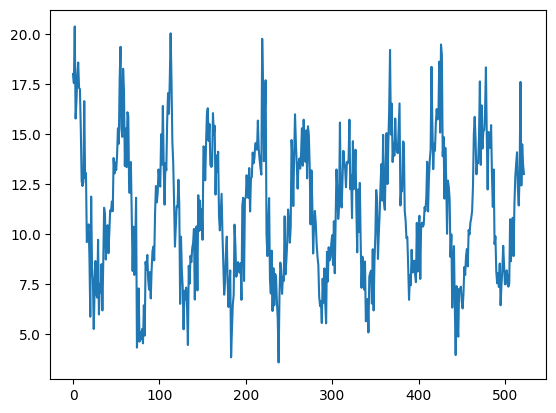

In [ ]:
df_w['linear'].plot()

Разделим новую выборку на обучение и тест.

In [ ]:
train_w = df_w[:-60]
test_w = df_w[-60:]

<Axes: >

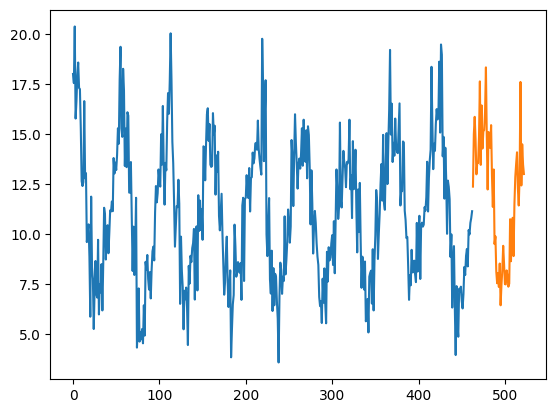

In [ ]:
train_w['linear'].plot()
test_w['linear'].plot()

# 2. Изучение структуры временного ряда

Поскольку была изменена частота дискретизации временного ряда, фактически, получились новые данные. Значит, их нужно заново исследовать.

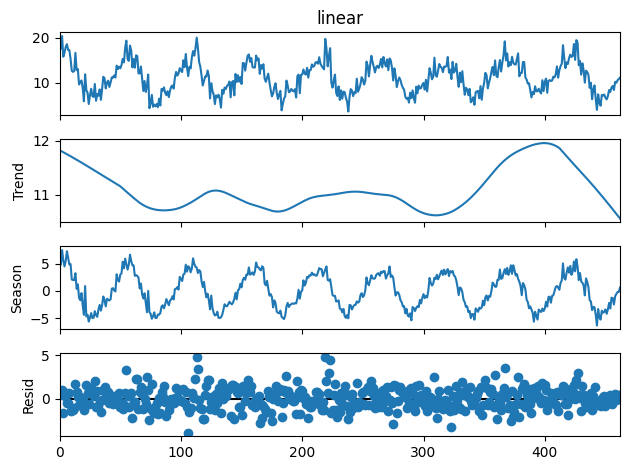

In [ ]:
from statsmodels.tsa.seasonal import STL


stl = STL(train_w['linear'], period=52)
result = stl.fit()
result.plot();

# 3. Определение параметров модели ARIMA (SARIMA)

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
adfuller(train_w['linear'])[1]

np.float64(1.9953474280030588e-14)

Новый сезон -- 52 недели (год, 365 дней).

In [ ]:
s = 52
train_w['linear'].diff(s)

,linear
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
458,-0.271429
459,-1.357143
460,-0.614286
461,-1.042857


In [ ]:
train_w['s_diff'] = train_w['linear'].diff(s)
train_w['s_diff']

/tmp/ipykernel_6794/42591359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_w['s_diff'] = train_w['linear'].diff(s)


,s_diff
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
458,-0.271429
459,-1.357143
460,-0.614286
461,-1.042857


In [ ]:
adfuller(train_w['s_diff'][s:])[1]

np.float64(7.149345035607417e-05)

In [ ]:
d = 0
D = 1

<Axes: >

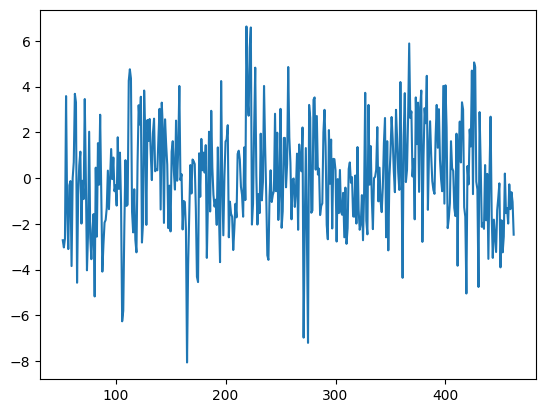

In [ ]:
train_w['s_diff'][s:].plot()

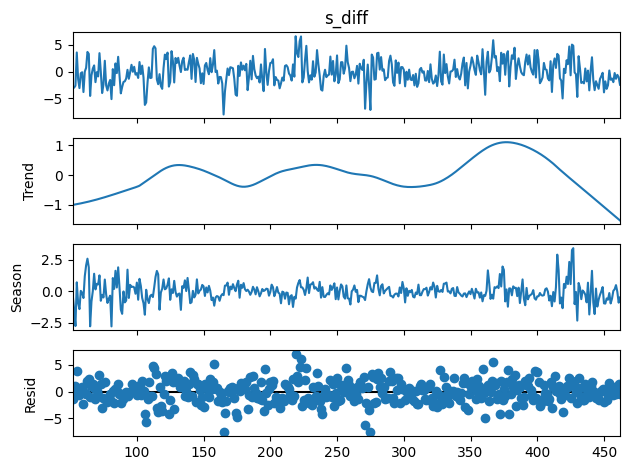

In [ ]:
stl = STL(train_w['s_diff'][s:], period=s)
result = stl.fit()
result.plot();

## 3.2. Исследование автокорреляции исходных данных

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

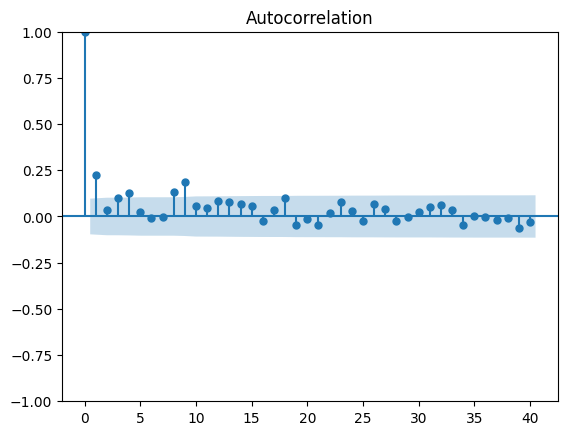

In [ ]:
plot_acf(train_w['s_diff'][s:], lags=40);

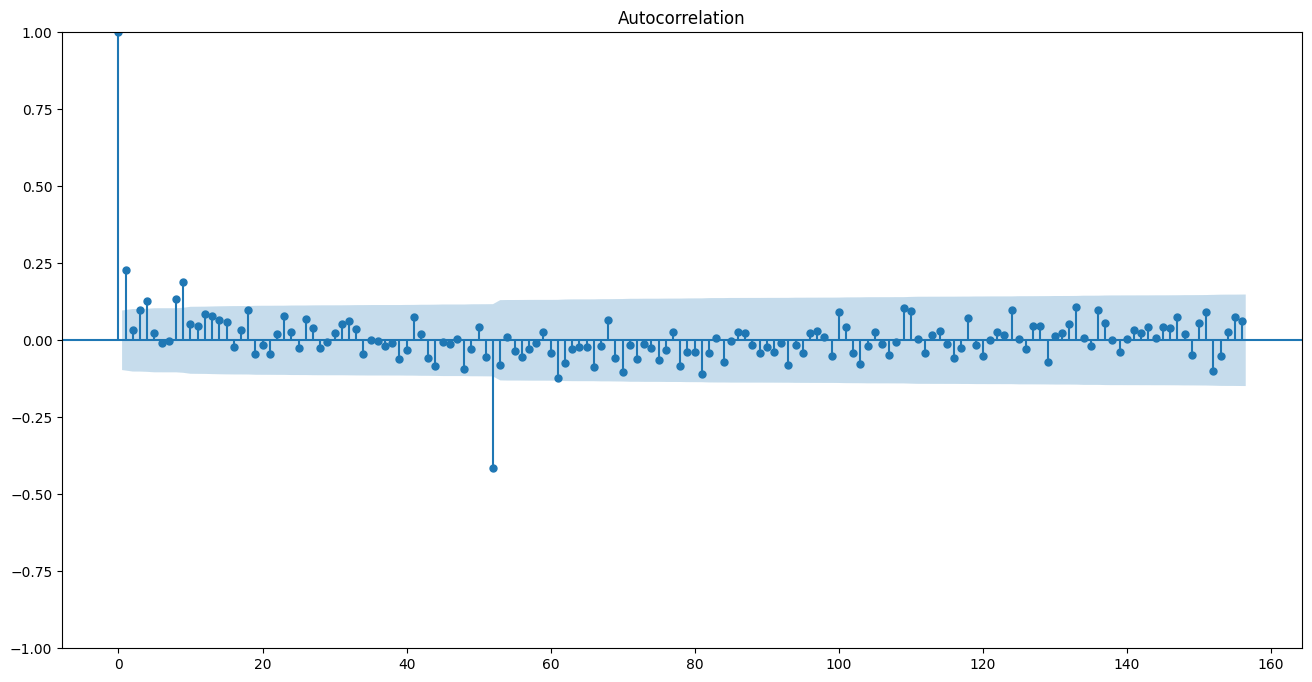

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_acf(train_w['s_diff'][s:], lags=3*s, ax=ax);

In [ ]:
q = 4
Q = 1

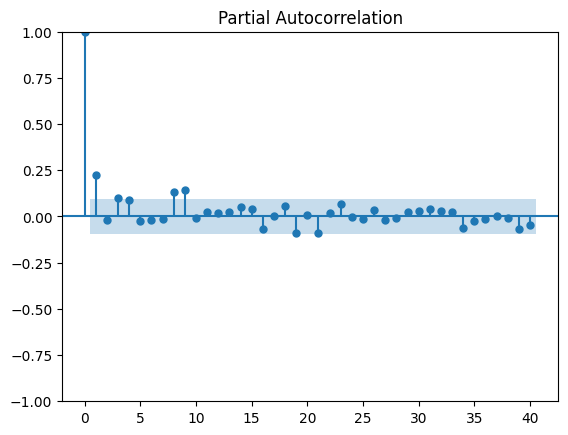

In [ ]:
plot_pacf(train_w['s_diff'][s:], lags=40);

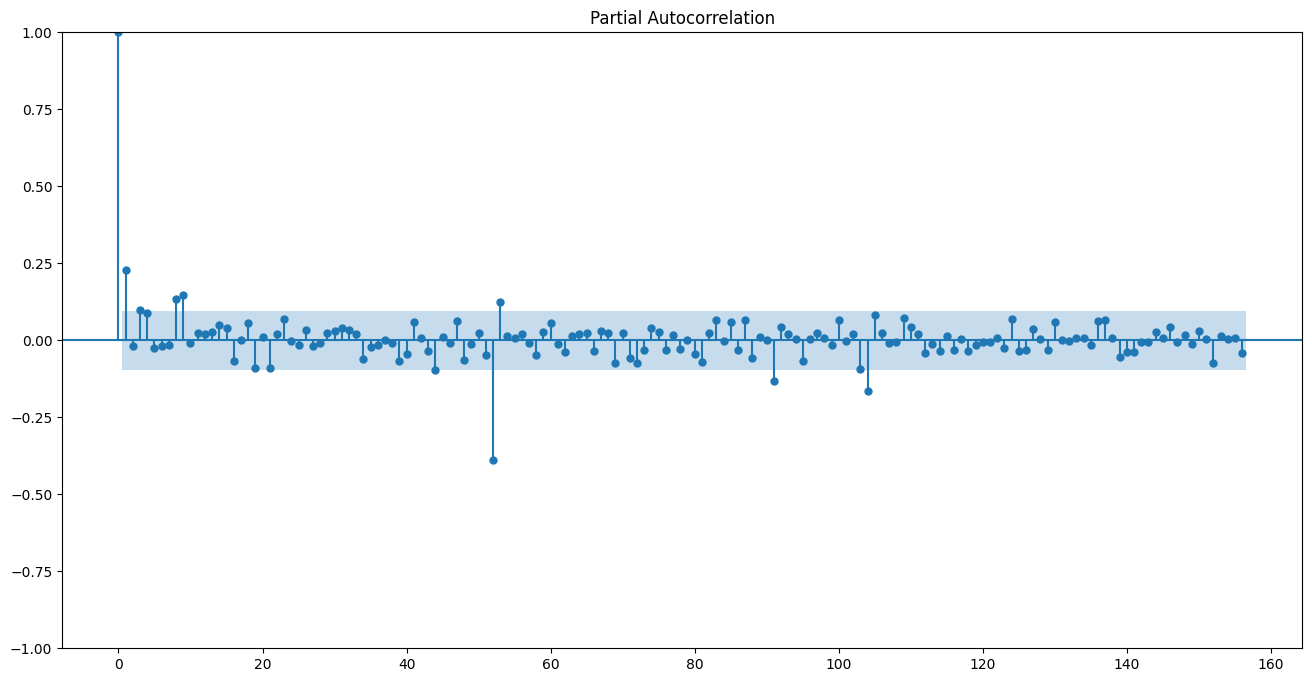

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_pacf(train_w['s_diff'][s:], lags=3*s, ax=ax);

In [ ]:
p = 8
P = 2

# 4. Обучение модели SARIMA. Подбор гиперпараметров

Обучение самих моделей -- это не совсем тривиальная задача. В классическом машинном обучении мы все привыкли, что достаточно написать функцию для Optuna, там прописать сетку, кросс-валидацию. И лучшая модель найдена.

Когда используется статистическая модель (к классу которых относятся ARIMA и SARIMA) недостаточно эту модель просто обучить и посчитать метрики. Нужно ее валидировать и исследовать, используя статистические тесты и визуализации.

Если эти тесты показывают хорошие результаты, еще и метрики хорошие, то модель можно использовать дальше.

In [ ]:
# !pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


Библиотека StatsForecast используется для подбора гиперпараметров моделей ARIMA/SARIMA. Она реализует два класса: `AutoARIMA` (обертка над моделью ARIMA/SARIMA из библиотеки statsmodels, инференс быстрее, может подбирать параметры автоматически по заданным интервалам) и `StatsForecast` (обобщение кросс-валидации и проверки модели).

Эти классы будут использоваться для подбора параметров p, q, P, Q.

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA


auto_arima = AutoARIMA(
    seasonal=True, season_length=s,
    max_p=p, max_q=q,
    max_P=P, max_Q=Q,
    d=d, D=D,
    stepwise=True,
    trace=True
)

sf = StatsForecast(
    models=[auto_arima],
    freq='W',
    n_jobs=2
)

Для стабильной работы библиотеки необходимо данные обернуть в специальный вид (чем-то похоже на Enta).

In [ ]:
train_df = pd.DataFrame({
    'unique_id': 'series_1',
    'ds': train_w['Date'],
    'y': train_w['linear']
})

Техника кросс-валидации во временных рядах используется не для проверки стабильности конкретных гиперпараметров, а для проверки стабильности всего обучения модели.

Исходные данные делятся на фолды, учитывающие временную структуру (см. картинку ниже), на каждом варианте обучающей и валидационной выборок подбираются гиперпараметры через класс AutoARIMA, а затем строится график ошибок, чтобы понять, слишком ли большой разброс от фолда к фолду.

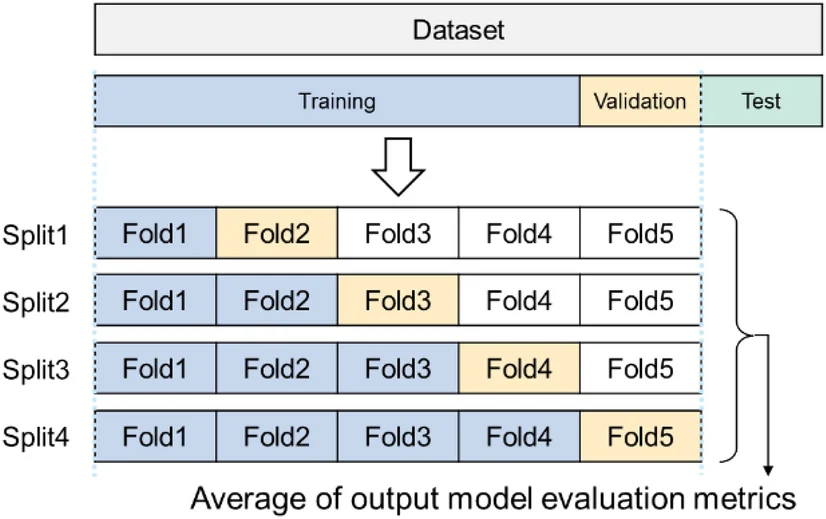

In [ ]:
cv_results = sf.cross_validation(
    df=train_df,
    h=7,
    n_windows=10,
    step_size=7
)


ARIMA(2,0,2)(1,1,1)[52] with drift        :1438.268425308024

ARIMA(0,0,0)(0,1,0)[52] with drift        :1541.7413889111704

ARIMA(1,0,0)(1,1,0)[52] with drift        :1454.1440247455657

ARIMA(0,0,1)(0,1,1)[52] with drift        :inf

ARIMA(0,0,0)(0,1,0)[52]                   :1539.7451359823046

ARIMA(2,0,2)(0,1,1)[52] with drift        :inf

ARIMA(2,0,2)(1,1,0)[52] with drift        :1597.365849656431

ARIMA(2,0,2)(2,1,1)[52] with drift        :inf

ARIMA(2,0,2)(0,1,0)[52] with drift        :1526.2991011675388

ARIMA(2,0,2)(2,1,0)[52] with drift        :inf

ARIMA(1,0,2)(1,1,1)[52] with drift        :1429.3276414612346

ARIMA(1,0,2)(0,1,1)[52] with drift        :inf

ARIMA(1,0,2)(1,1,0)[52] with drift        :1456.5005322015306

ARIMA(1,0,2)(2,1,1)[52] with drift        :1427.6311315246032

ARIMA(1,0,2)(2,1,0)[52] with drift        :inf

ARIMA(0,0,2)(2,1,1)[52] with drift        :1427.6379400644175

ARIMA(1,0,1)(2,1,1)[52] with drift        :1429.72341432956

ARIMA(1,0,3)(2,1,1)[52

получается вот такая табличка.

In [ ]:
cv_results

,unique_id,ds,cutoff,y,AutoARIMA
0,series_1,1988-07-17,1988-07-10,8.085714,7.386904
1,series_1,1988-07-24,1988-07-10,8.100000,5.035175
2,series_1,1988-07-31,1988-07-10,8.671429,7.670854
3,series_1,1988-08-07,1988-07-10,8.000000,7.762247
4,series_1,1988-08-14,1988-07-10,7.600000,7.380623
...,...,...,...,...,...
65,series_1,1989-10-15,1989-09-24,10.200000,9.768964
66,series_1,1989-10-22,1989-09-24,9.985714,10.076215
67,series_1,1989-10-29,1989-09-24,10.557143,11.222724
68,series_1,1989-11-05,1989-09-24,10.800000,12.845090


Ее можно преобразовать и сгруппировать, чтобы построить график ошибок (по метрике MAE и MAPE, например).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


errors_by_cutoff = cv_results.groupby('cutoff').apply(lambda df: pd.Series({
    'mae': mean_absolute_error(df['y'], df['AutoARIMA']),
    'mape': mean_absolute_percentage_error(df['y'], df['AutoARIMA']),
})).reset_index()

errors_by_cutoff

/tmp/ipykernel_21340/2608101141.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  errors_by_cutoff = cv_results.groupby('cutoff').apply(lambda df: pd.Series({


,cutoff,mae,mape
0,1988-07-10,1.207351,0.135599
1,1988-08-28,0.886976,0.093137
2,1988-10-16,1.075603,0.090594
3,1988-12-04,1.827854,0.113854
4,1989-01-22,2.906159,0.160874
5,1989-03-12,1.164063,0.094112
6,1989-04-30,1.236737,0.145624
7,1989-06-18,1.501135,0.281629
8,1989-08-06,1.045613,0.144438
9,1989-09-24,0.818218,0.080634


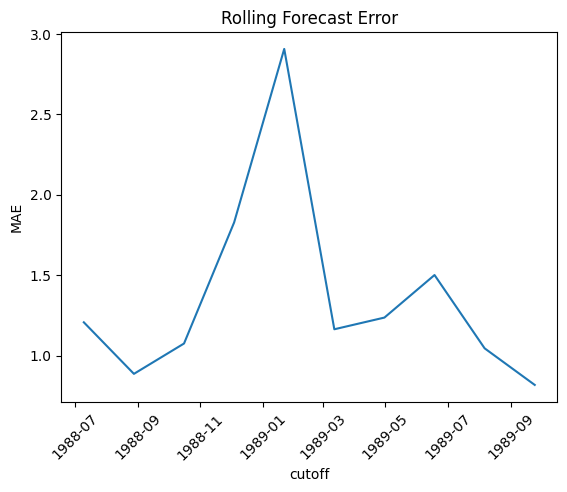

In [ ]:
plt.plot(errors_by_cutoff['cutoff'], errors_by_cutoff['mae']);
plt.xlabel('cutoff');
plt.ylabel('MAE');
plt.title('Rolling Forecast Error');
plt.xticks(rotation=45);

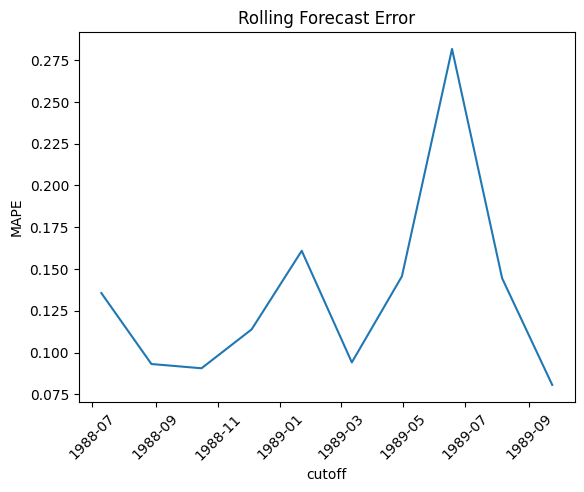

In [ ]:
plt.plot(errors_by_cutoff['cutoff'], errors_by_cutoff['mape']);
plt.xlabel('cutoff');
plt.ylabel('MAPE');
plt.title('Rolling Forecast Error');
plt.xticks(rotation=45);

В результате получаются такие графики. По ним можно увидеть, что разброс абсолютной и процентной ошибок невелик, значит, обучение от фолда к фолду стабильно. И модель корректно улавливает периодические и трендовые зависимости в данных.

Раз обучение стабильно, можно попробовать определить лучшие параметры. На исходном датасете обучаем модель ARIMA/SARIMA.

In [ ]:
sf.fit(train_df)


ARIMA(2,0,2)(1,1,1)[52] with drift        :inf

ARIMA(0,0,0)(0,1,0)[52] with drift        :1858.9818885072305

ARIMA(1,0,0)(1,1,0)[52] with drift        :1740.7910581582055

ARIMA(0,0,1)(0,1,1)[52] with drift        :inf

ARIMA(0,0,0)(0,1,0)[52]                   :1857.044572933714

ARIMA(1,0,0)(0,1,0)[52] with drift        :1839.1703473325977

ARIMA(1,0,0)(2,1,0)[52] with drift        :inf

ARIMA(1,0,0)(1,1,1)[52] with drift        :1695.7400457994238

ARIMA(1,0,0)(0,1,1)[52] with drift        :inf

ARIMA(1,0,0)(2,1,1)[52] with drift        :1699.63590983868

ARIMA(0,0,0)(1,1,1)[52] with drift        :1725.7134974651935

ARIMA(2,0,0)(1,1,1)[52] with drift        :1697.7767869776544

ARIMA(1,0,1)(1,1,1)[52] with drift        :1695.371015193829

ARIMA(1,0,1)(0,1,1)[52] with drift        :inf

ARIMA(1,0,1)(1,1,0)[52] with drift        :1742.5795122890988

ARIMA(1,0,1)(2,1,1)[52] with drift        :1703.7656553059592

ARIMA(1,0,1)(0,1,0)[52] with drift        :1840.890438217922

ARIMA(1,

StatsForecast(models=[AutoARIMA])

Выдаются лучшие параметры, но это еще не итоговая модель! Будем использовать модель из библиотеки statsmodels, поскольку она имеет мощный инструментарий по статистическому анализу итогового алгоритма.

Кстати, лучшая модель считается по специальной метрике, которая называется Критерий Акаике (AIC-score):

$$\text{AIC} = 2k - 2\ln(L),$$

где:
- $k$ -- число подбираемых параметров рассматриваемой статистической модели;
- $L$ -- максимум функции правдоподобия модели.

Эта метрика вычисляется исключительно на основе обучающей выборки, ее нельзя использовать для определения качества модели. Она показывает, насколько модель хорошо описывает данные и насколько востребованы коэффиценты $\text{AR(p)}$ и $\text{MA(q)}$ (метрика больше, если много лишних коэффициентов, которые не особо влияют на максимизацию правдоподобия).

Метрика безразмерна, ее обычно используют для сравнения разных моделей между собой (чем критерий акаике меньше, тем лучше).

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model = SARIMAX(
    train_df['y'],
    order=(1, 0, 2),
    seasonal_order=(1, 1, 1, s)
)

results = model.fit()

# 5. Изучение модели ARIMA/SARIMA

Первым делом выведем `.summary()` модели: оценки значимости коэффициентов авторегрессии и скользящего среднего ошибки, а также анализ распределения остатков.

| Блок | Параметр | Что это | Как интерпретировать | На что смотреть |
|------|----------|--------|----------------------|-----------------|
| Общая информация | Dep. Variable | Целевая переменная | Имя прогнозируемого ряда | Не критично |
| Общая информация | No. Observations | Количество наблюдений | Размер обучающей выборки | Должно быть достаточно большим (желательно > 100) |
| Модель | Model | Структура модели | (p,d,q)(P,D,Q,m) | Проверить соответствие данным (сезонность, дифференцирование) |
| Качество | Log Likelihood | Логарифм правдоподобия | Чем выше (менее отрицательное), тем лучше | Используется только для сравнения |
| Качество | AIC | Информационный критерий Акаике | Баланс качества и сложности модели | Меньше = лучше |
| Качество | BIC | Байесовский критерий | Сильнее штрафует сложность | Меньше = лучше |
| Качество | HQIC | Критерий Ханнана-Куинна | Компромисс AIC/BIC | Меньше = лучше |
| Коэффициенты | coef | Оценка параметра | Влияние соответствующего лага | Сам по себе не интерпретируется |
| Коэффициенты | std err | Стандартная ошибка | Оценка неопределённости coef | Меньше = лучше |
| Коэффициенты | z | z-статистика | coef / std err | Используется для p-value |
| Коэффициенты | P>\|z\| | p-value | Значимость параметра | < 0.05 → параметр значим |
| Коэффициенты | [0.025, 0.975] | Доверительный интервал | Интервал для coef | Не должен содержать 0 |
| Диагностика | Ljung-Box (Q) | Тест на автокорреляцию остатков | Проверяет независимость остатков | p-value > 0.05 → хорошо |
| Диагностика | Prob(Q) | p-value Ljung-Box | Вероятность гипотезы “нет автокорреляции” | > 0.05 → остатки как белый шум |
| Диагностика | Jarque-Bera (JB) | Тест нормальности | Проверяет нормальность распределения | p-value > 0.05 → хорошо (но не критично) |
| Диагностика | Prob(JB) | p-value JB | Вероятность нормальности | < 0.05 → отклонение от нормальности |
| Диагностика | Heteroskedasticity (H) | Тест гетероскедастичности | Проверяет постоянство дисперсии | p-value > 0.05 → хорошо |
| Диагностика | Prob(H) | p-value H | Вероятность постоянной дисперсии | > 0.05 → дисперсия стабильна |
| Диагностика | Skew | Асимметрия распределения | Смещение распределения остатков | ≈ 0 → хорошо |
| Диагностика | Kurtosis | Эксцесс | “Тяжесть хвостов” | ≈ 3 → нормальное распределение |
| Параметры модели | ar.Lk | AR-компонента | Зависимость от y(t-k) | Значимость + знак |
| Параметры модели | ma.Lk | MA-компонента | Зависимость от ошибок | Значимость + знак |
| Параметры модели | ar.S.Lm | Сезонный AR | Зависимость от y(t-m) | Проверить значимость |
| Параметры модели | ma.S.Lm | Сезонный MA | Зависимость от сезонных ошибок | Проверить значимость |
| Параметры модели | sigma2 | Дисперсия ошибок | Величина шума модели | Меньше = лучше |

Модель считается хорошей, если:
1. все коэффициенты должны быть значимы:
   - P>|z| < 0.05;
   - доверительный интервал не содержит 0;

2. остатки должны быть "белым шумом": Ljung-Box p-value > 0.05;

3. модель не должна быть переусложнена: для этого нужно сравнивать AIC / BIC с альтернативами;

4. желательно проверять то, что:
   - отсутствует гетероскедастичность (Prob(H) > 0.05);
   - остатки близки к нормальным (Prob(JB) > 0.05).

Если какие-то свойства не выполняются, это не значит, что модель плохая. Нужно посчитать нормальные метрики качества: если они вас устраивают, то модель принимвается. Но в идеале, конечно, чтобы все выполнялось.

Статистический анализ используется для уверенности, что модель корректная.

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  463
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -834.012
Date:                              Wed, 15 Apr 2026   AIC                           1680.023
Time:                                      09:36:10   BIC                           1704.135
Sample:                                           0   HQIC                          1689.561
                                              - 463                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9082      0.062     14.563      0.000       0.786       1.030
ma.L1         -0.6539      0.077     -8.520      0.000      -0.804      -0.504
ma.L2         -0.1320      0.061     -2.165      0.030      -0.251      -0.013
ar.S.L52      -0.0293      0.074     -0.396      0.692      -0.174       0.116
ma.S.L52      -0.7978      0.098     -8.112      0.000      -0.991      -0.605
sigma2         2.9698      0.242     12.290      0.000       2.496       3.443
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 7.70
Prob(Q):                              0.91   Prob(JB):                         0.02
Heteroskedasticity (H):               0.84   Skew:                             0.26
Prob(H) (two-sided):                  0.31   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Также можно вывести метод `.plot_diagnostics()`, который визуализирует информацию об остатках модели.

Метод `results.plot_diagnostics()` визуализирует диагностические графики остатков модели ARIMA/SARIMA. Цель -- проверить, удовлетворяют ли остатки предположениям модели (белый шум, нормальность, независимость).

Метод строит 4 графика.

1. Standardized residuals (стандартизированные остатки). Показывает остатки модели во времени (после нормализации). Остатки должны колебаться вокруг 0, не должно быть тренда или сезонности, не должно быть “кластеров” высокой/низкой дисперсии. Если наблюдается тренд, то модель не уловила структуру в данных. Если наблюдается сезонность, то не учтена сезонная компонента. Если присутствуют всплески, необходимо провести работу по детекции выбросов.

2. Histogram + KDE (распределение остатков). Показывает гистограмму остатков модели (разница между истинными и предсказанными значениями на обучающенй выборке) и оценку функции плотности распределения остатков. Для сравнения наложена стандартная нормальная кривая. Полученное распределение должно быть близко к стандартному нормальному (условия Гаусса-Маркова). Если присутствует скошенность гистограммы, то у модели высокий bias предсказаний. Тяжёлые хвосты, значит, с выбросами плохо поработали. Смещение от 0 говорит о систематических ошибках модели.

3. Normal Q-Q plot. Показывает сравнение распределения остатков с нормальным в графической форме. Точки должны лежать вдоль прямой линии. Отклонения на концах -- признак тяжелых хвостов, S-образная форма -- ненормальности распределения,сильные отклонения -- плохое обобщение случайных шумов.

4. Correlogram (ACF остатков). Показывает автокорреляцию остатков на разных лагах. Все значения должны лежать внутри доверительных интервалов, не должно быть значимых пиков (за исключением нулевого лага). В противном случае, такая ситуация будет означать, что модель не учла зависимости из данных.

Идеальных графиков почти не бывает. Небольшие отклонения допустимы, если модель дает хорошее качество прогноза.

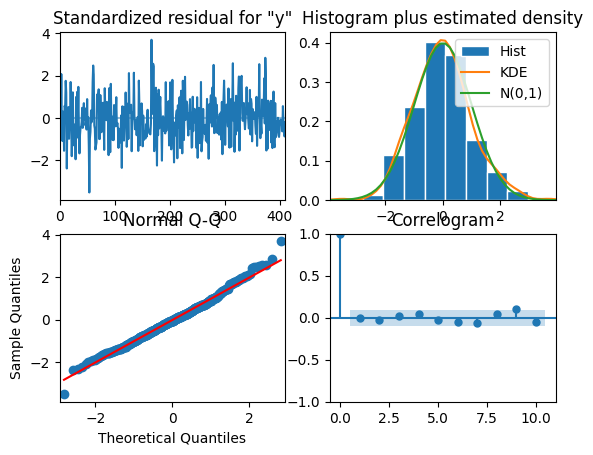

In [ ]:
results.plot_diagnostics();

# 6. Вычисление метрик модели

In [ ]:
pred = results.forecast(steps=len(test_w))
pred

,predicted_mean
463,12.026867
464,12.284065
465,12.948391
466,13.295752
467,14.288150
468,13.990985
469,13.832849
470,14.681292
471,14.955323
472,14.174043


In [ ]:
train_w

,Date,linear,s_diff
0,1981-01-04,18.000000,NaN
1,1981-01-11,17.542857,NaN
2,1981-01-18,20.371429,NaN
3,1981-01-25,15.771429,NaN
4,1981-02-01,16.657143,NaN
...,...,...,...
458,1989-10-15,10.200000,-0.271429
459,1989-10-22,9.985714,-1.357143
460,1989-10-29,10.557143,-0.614286
461,1989-11-05,10.800000,-1.042857


In [ ]:
test_w

,Date,linear
463,1989-11-19,12.371429
464,1989-11-26,14.985714
465,1989-12-03,15.857143
466,1989-12-10,14.757143
467,1989-12-17,12.985714
468,1989-12-24,13.585714
469,1989-12-31,13.557143
470,1990-01-07,14.885714
471,1990-01-14,17.628571
472,1990-01-21,13.457143


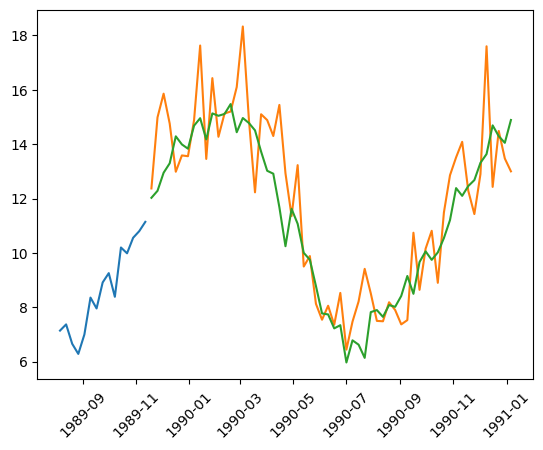

In [ ]:
plt.plot(train_w['Date'][-15:], train_w['linear'][-15:])
plt.plot(test_w['Date'], test_w['linear'])
plt.plot(test_w['Date'], pred.values)

plt.xticks(rotation=45);

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_forecast(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    smape = float(100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ))
    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MSE': mse,
        'MAPE (%)': mape,
        'sMAPE (%)': smape,
        'R2': r2
    }

In [ ]:
evaluate_forecast(test_w['linear'], pred)

{'MAE': 1.1932570091560035,
 'RMSE': 1.566254490178691,
 'MSE': 2.453153128004911,
 'MAPE (%)': 9.712836880638301,
 'sMAPE (%)': 10.154677090171607,
 'R2': 0.7535250519110059}